<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/Calculus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 機械学習に必要な微分積分

In [1]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 21.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=91753048aae5bca4cde91cf2bd2222a6f6a1375c33c5237e7bbec59013a4893f
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


## 活性化関数とその微分

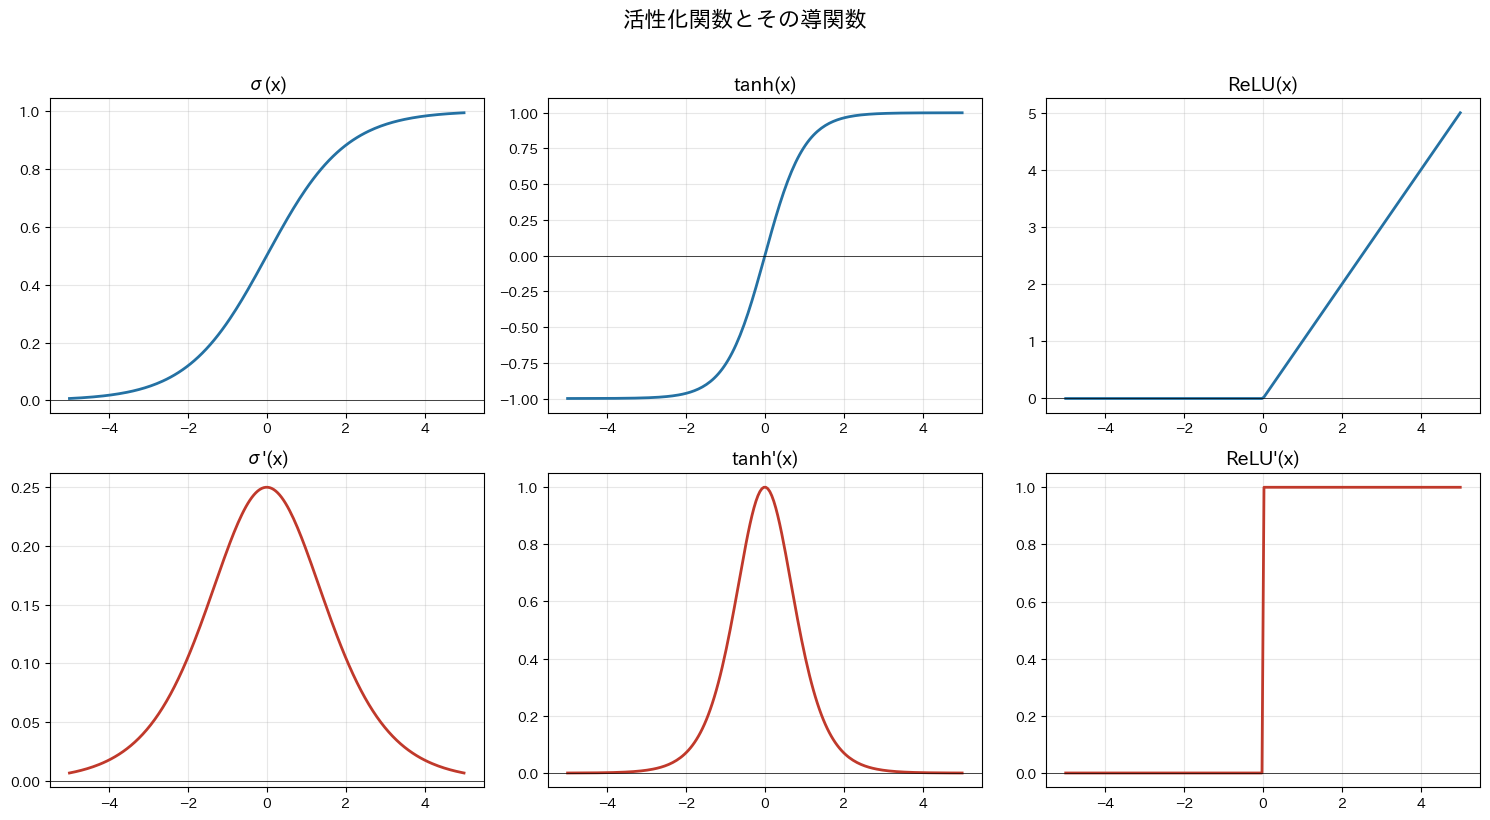

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

x = np.linspace(-5, 5, 200)

# 各活性化関数とその導関数
sigmoid = 1 / (1 + np.exp(-x))
sigmoid_grad = sigmoid * (1 - sigmoid)

tanh_val = np.tanh(x)
tanh_grad = 1 - tanh_val**2

relu_val = np.maximum(0, x)
relu_grad = (x > 0).astype(float)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, val, name in zip(axes[0], [sigmoid, tanh_val, relu_val],
                          ['σ(x)', 'tanh(x)', 'ReLU(x)']):
    ax.plot(x, val, linewidth=2, color='#2471A3')
    ax.set_title(name, fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)

for ax, grad, name in zip(axes[1], [sigmoid_grad, tanh_grad, relu_grad],
                           ["σ'(x)", "tanh'(x)", "ReLU'(x)"]):
    ax.plot(x, grad, linewidth=2, color='#C0392B')
    ax.set_title(name, fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)

plt.suptitle('活性化関数とその導関数', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150)
plt.show()


## 勾配

In [3]:
# 勾配の数値計算と解析計算の比較
def mse_loss(w, b, X, y):
    return np.mean((w * X + b - y) ** 2)

def mse_gradient(w, b, X, y):
    m = len(X)
    residual = w * X + b - y
    dw = 2 * np.mean(residual * X)
    db = 2 * np.mean(residual)
    return dw, db

# サンプルデータ
np.random.seed(42)
X = np.random.randn(50)
y = 3.0 * X + 1.0 + np.random.randn(50) * 0.5

# 数値微分（中心差分）
def numerical_gradient(f, params, idx, h=1e-5):
    params_plus = params.copy()
    params_minus = params.copy()
    params_plus[idx] += h
    params_minus[idx] -= h
    return (f(*params_plus, X, y) - f(*params_minus, X, y)) / (2 * h)

w, b = 2.0, 0.5
dw_analytic, db_analytic = mse_gradient(w, b, X, y)
dw_numeric = numerical_gradient(mse_loss, [w, b], 0)
db_numeric = numerical_gradient(mse_loss, [w, b], 1)

print("=== 勾配の検証 ===")
print(f"∂L/∂w: 解析={dw_analytic:.6f}, 数値={dw_numeric:.6f}, "
      f"差={abs(dw_analytic - dw_numeric):.2e}")
print(f"∂L/∂b: 解析={db_analytic:.6f}, 数値={db_numeric:.6f}, "
      f"差={abs(db_analytic - db_numeric):.2e}")


=== 勾配の検証 ===
∂L/∂w: 解析=-1.668857, 数値=-1.668857, 差=2.27e-11
∂L/∂b: 解析=-0.566833, 数値=-0.566833, 差=5.23e-13


## 勾配降下法の実装例

Epoch   0: Loss = 9.1128, w = 0.5187, b = 0.1841
Epoch  10: Loss = 0.4504, w = 2.6582, b = 0.9197
Epoch  20: Loss = 0.2451, w = 2.9898, b = 1.0264
Epoch  30: Loss = 0.2403, w = 3.0411, b = 1.0422
Epoch  40: Loss = 0.2401, w = 3.0490, b = 1.0446

最終結果: w = 3.0502 (真値: 3.0), b = 1.0449 (真値: 1.0)


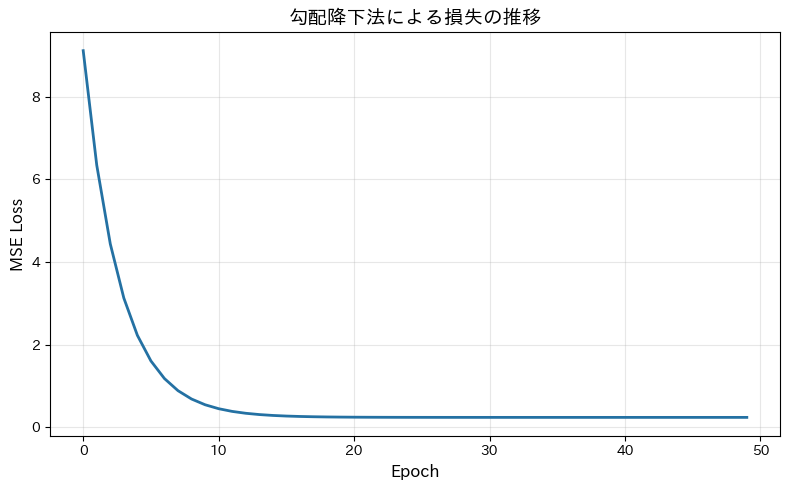

In [4]:
# 線形回帰を勾配降下法で学習する
np.random.seed(42)
X_data = np.random.randn(200)
y_data = 3.0 * X_data + 1.0 + np.random.randn(200) * 0.5

# パラメータの初期化
w, b = 0.0, 0.0
alpha = 0.1      # 学習率
n_epochs = 50
m = len(X_data)

history = []

for epoch in range(n_epochs):
    # 予測
    y_pred = w * X_data + b

    # 損失（MSE）
    loss = np.mean((y_pred - y_data) ** 2)
    history.append(loss)

    # 勾配の計算
    dw = (2 / m) * np.sum((y_pred - y_data) * X_data)
    db = (2 / m) * np.sum(y_pred - y_data)

    # パラメータの更新
    w -= alpha * dw
    b -= alpha * db

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}: Loss = {loss:.4f}, w = {w:.4f}, b = {b:.4f}")

print(f"\n最終結果: w = {w:.4f} (真値: 3.0), b = {b:.4f} (真値: 1.0)")

# 損失の推移をプロット
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history, linewidth=2, color='#2471A3')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('勾配降下法による損失の推移', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gradient_descent_loss.png', dpi=150)
plt.show()


## 逆伝搬の実装

In [5]:
# 2層ニューラルネットワークの順伝播と逆伝播を手動実装
np.random.seed(42)

# データ生成（XOR 問題）
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train = np.array([[0], [1], [1], [0]])

# ネットワーク構造: 2入力 → 4隠れ → 1出力
n_input, n_hidden, n_output = 2, 4, 1

# パラメータの初期化
W1 = np.random.randn(n_input, n_hidden) * 0.5
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_output) * 0.5
b2 = np.zeros((1, n_output))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

alpha = 1.0
losses = []

for epoch in range(10000):
    # 順伝播
    z1 = X_train @ W1 + b1        # (4, 4)
    h = sigmoid(z1)                 # (4, 4)
    z2 = h @ W2 + b2               # (4, 1)
    a = sigmoid(z2)                 # (4, 1) = 予測

    # 損失（交差エントロピー）
    loss = -np.mean(y_train * np.log(a + 1e-8) +
                    (1 - y_train) * np.log(1 - a + 1e-8))
    losses.append(loss)

    # 逆伝播
    m = len(X_train)
    dz2 = a - y_train                         # (4, 1) ← ∂L/∂z2
    dW2 = (1/m) * h.T @ dz2                   # (4, 1) ← ∂L/∂W2
    db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
    dh = dz2 @ W2.T                            # (4, 4) ← ∂L/∂h
    dz1 = dh * h * (1 - h)                     # (4, 4) ← アダマール積で σ'
    dW1 = (1/m) * X_train.T @ dz1              # (2, 4) ← ∂L/∂W1
    db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)

    # パラメータ更新
    W2 -= alpha * dW2
    b2 -= alpha * db2
    W1 -= alpha * dW1
    b1 -= alpha * db1

# 結果の確認
print("=== XOR 問題の学習結果 ===\n")
print("入力   → 予測値    → 判定")
for i in range(4):
    pred = a[i, 0]
    label = 1 if pred >= 0.5 else 0
    print(f"{X_train[i]} → {pred:.4f}    → {label}")


=== XOR 問題の学習結果 ===

入力   → 予測値    → 判定
[0 0] → 0.0011    → 0
[0 1] → 0.9993    → 1
[1 0] → 0.9993    → 1
[1 1] → 0.0006    → 0


## テイラー展開の近似精度

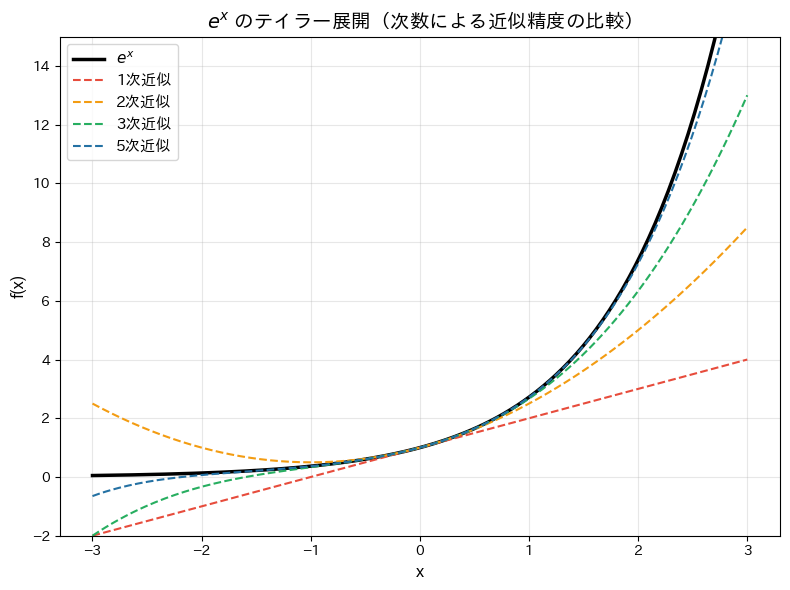

In [8]:
import numpy as np
import math

# テイラー展開の近似精度の可視化
x = np.linspace(-3, 3, 200)

# e^x の厳密値
exact = np.exp(x)

# 各次数のテイラー近似
approx = {}
for order in [1, 2, 3, 5]:
    approx[order] = sum(x**k / math.factorial(k) for k in range(order + 1))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, exact, 'k-', linewidth=2.5, label='$e^x$')
colors = ['#E74C3C', '#F39C12', '#27AE60', '#2471A3']
for (order, vals), color in zip(approx.items(), colors):
    ax.plot(x, vals, '--', linewidth=1.5, color=color, label=f'{order}次近似')

ax.set_ylim(-2, 15)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.set_title('$e^x$ のテイラー展開（次数による近似精度の比較）', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('taylor_expansion.png', dpi=150)
plt.show()


## モンテカルロ積分

In [11]:
# モンテカルロ積分の例: x^2 の積分
N_samples = [100, 1000, 10000, 100000]
exact = 1/3

print("=== モンテカルロ積分: x^2 の積分 ===\n")
print(f"厳密値: {exact:.6f}\n")
for N in N_samples:
    samples = np.random.uniform(0, 1, N) # [0,1]の範囲で積分
    estimate = np.mean(samples ** 2)
    error = abs(estimate - exact)
    print(f"N = {N:>7,d}: 推定値 = {estimate:.6f}, 誤差 = {error:.6f}")

# π の推定（円の面積を利用）
N = 100000
points = np.random.uniform(-1, 1, (N, 2))
inside = np.sum(points[:, 0]**2 + points[:, 1]**2 <= 1)
pi_estimate = 4 * inside / N
print(f"\nπ の推定: {pi_estimate:.4f}（真値: {np.pi:.4f}）")


=== モンテカルロ積分: x^2 の積分 ===

厳密値: 0.333333

N =     100: 推定値 = 0.338358, 誤差 = 0.005025
N =   1,000: 推定値 = 0.338702, 誤差 = 0.005369
N =  10,000: 推定値 = 0.338200, 誤差 = 0.004867
N = 100,000: 推定値 = 0.334051, 誤差 = 0.000718

π の推定: 3.1363（真値: 3.1416）


## 最適化手法の比較

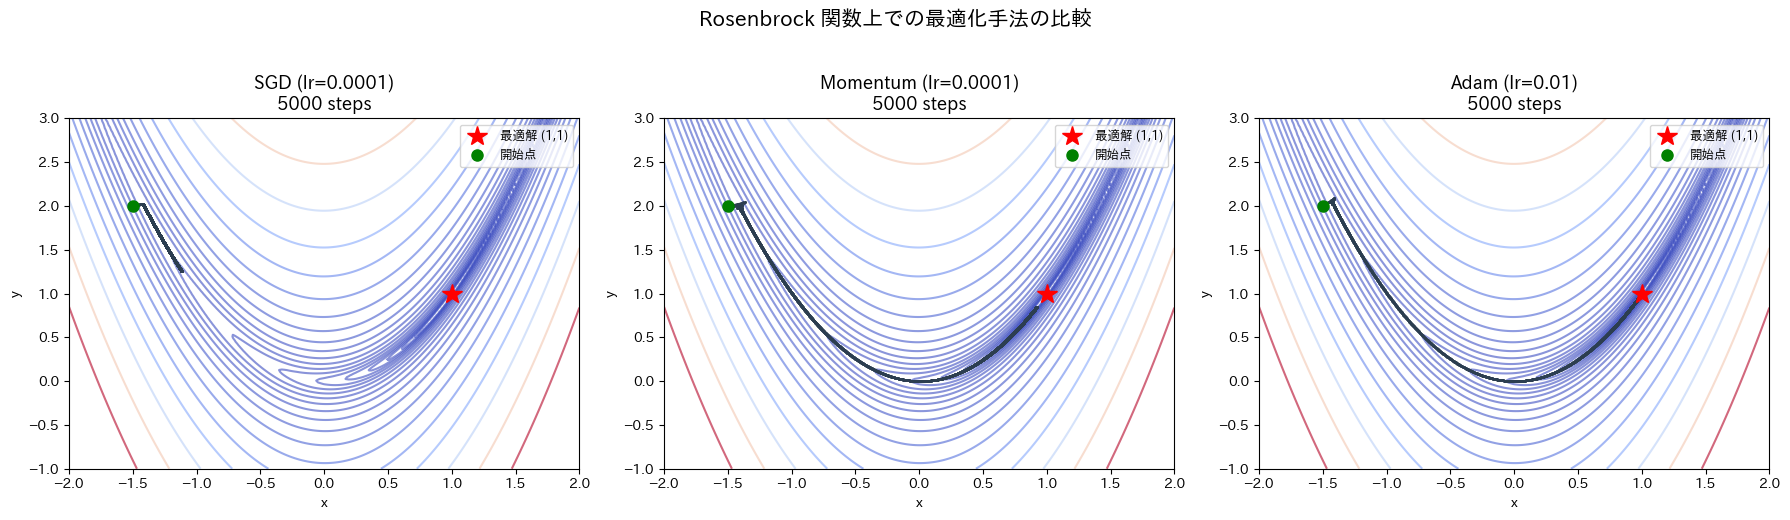

In [12]:
# 各最適化手法の挙動を可視化（Rosenbrock 関数上で比較）
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    dx = -2*(1-x) - 400*x*(y - x**2)
    dy = 200*(y - x**2)
    return np.array([dx, dy])

def run_optimizer(optimizer_name, x0, y0, lr, n_steps):
    path = [(x0, y0)]
    x, y = x0, y0
    m_x, m_y = 0, 0          # モメンタム用
    v_x, v_y = 0, 0          # Adam 用
    beta1, beta2, eps = 0.9, 0.999, 1e-8

    for t in range(1, n_steps + 1):
        gx, gy = rosenbrock_grad(x, y)

        if optimizer_name == 'SGD':
            x -= lr * gx
            y -= lr * gy
        elif optimizer_name == 'Momentum':
            m_x = 0.9 * m_x + gx
            m_y = 0.9 * m_y + gy
            x -= lr * m_x
            y -= lr * m_y
        elif optimizer_name == 'Adam':
            m_x = beta1 * m_x + (1-beta1) * gx
            m_y = beta1 * m_y + (1-beta1) * gy
            v_x = beta2 * v_x + (1-beta2) * gx**2
            v_y = beta2 * v_y + (1-beta2) * gy**2
            mhat_x = m_x / (1 - beta1**t)
            mhat_y = m_y / (1 - beta1**t)
            vhat_x = v_x / (1 - beta2**t)
            vhat_y = v_y / (1 - beta2**t)
            x -= lr * mhat_x / (np.sqrt(vhat_x) + eps)
            y -= lr * mhat_y / (np.sqrt(vhat_y) + eps)

        path.append((x, y))
    return np.array(path)

# 等高線の準備
xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-1, 3, 200))
zz = rosenbrock(xx, yy)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    ('SGD', 0.0001, 5000),
    ('Momentum', 0.0001, 5000),
    ('Adam', 0.01, 5000),
]

for ax, (name, lr, steps) in zip(axes, configs):
    path = run_optimizer(name, -1.5, 2.0, lr, steps)
    ax.contour(xx, yy, zz, levels=np.logspace(-1, 3, 20), cmap='coolwarm', alpha=0.6)
    ax.plot(path[:, 0], path[:, 1], '.-', markersize=2, linewidth=0.8, color='#2C3E50')
    ax.plot(1, 1, 'r*', markersize=15, label='最適解 (1,1)')
    ax.plot(path[0, 0], path[0, 1], 'go', markersize=8, label='開始点')
    ax.set_title(f'{name} (lr={lr})\n{len(path)-1} steps', fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=9)

plt.suptitle('Rosenbrock 関数上での最適化手法の比較', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()


## 自動微分

In [15]:
# PyTorch による自動微分の例
import torch

x = torch.tensor([2.0], requires_grad=True)
w = torch.tensor([3.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)

# 順伝播
z = w * x + b            # z = 3*2 + 1 = 7
a = torch.sigmoid(z)     # a = σ(7) → 約0.999
loss = -torch.log(a)     # loss → 約0.001

# 逆伝播（自動微分）
loss.backward()

print("=== PyTorchによる逆伝播の計算 ===\n")
print(f"∂L/∂w = {w.grad.item():.6f}")
print(f"∂L/∂b = {b.grad.item():.6f}")
print(f"∂L/∂x = {x.grad.item():.6f}")

# NumPy での手動計算で同じ結果を検証
x, w, b = 2.0, 3.0, 1.0
z = w * x + b
a = 1 / (1 + np.exp(-z))
loss = -np.log(a)

# 逆伝播を手動で計算
dL_da = -1/a
da_dz = a * (1 - a)
dz_dw = x
dz_db = 1
dz_dx = w

dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db
dL_dx = dL_da * da_dz * dz_dx

print("\n=== 手動による逆伝播の計算 ===\n")
print(f"z = {z:.4f}, a = σ(z) = {a:.6f}, loss = -log(a) = {loss:.6f}")
print(f"∂L/∂w = {dL_dw:.6f}")
print(f"∂L/∂b = {dL_db:.6f}")
print(f"∂L/∂x = {dL_dx:.6f}")


=== PyTorchによる逆伝播の計算 ===

∂L/∂w = -0.001822
∂L/∂b = -0.000911
∂L/∂x = -0.002733

=== 手動による逆伝播の計算 ===

z = 7.0000, a = σ(z) = 0.999089, loss = -log(a) = 0.000911
∂L/∂w = -0.001822
∂L/∂b = -0.000911
∂L/∂x = -0.002733
